# Phân Tích Chỉ Số Khí Tượng Việt Nam (2009-2021)
## Ứng Dụng Học Máy trong Dự Báo và Phân Loại Thời Tiết

**Phạm vi dữ liệu:** 40 tỉnh/thành phố Việt Nam, từ 1/1/2009 đến 18/6/2021

---

## 0. SETUP - Cài Đặt Thư Viện và Tải Dữ Liệu

In [6]:
# Import thư viện cốt lõi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Các thư viện đã được import thành công!')

Các thư viện đã được import thành công!


In [7]:
# Tải dữ liệu thời tiết Việt Nam
df = pd.read_csv('../Data/weather.csv')

# Xem thông tin cơ bản
print('Shape của dữ liệu:', df.shape)
print('\nCác cột trong dữ liệu:')
print(df.columns.tolist())
print('\nThông tin chi tiết:')
print(df.info())
print('\n5 dòng đầu tiên:')
df.head()

Shape của dữ liệu: (181960, 10)

Các cột trong dữ liệu:
['province', 'max_temp', 'min_temp', 'wind_speed', 'wind_direction', 'rain', 'humidity', 'cloud_cover', 'pressure', 'date']

Thông tin chi tiết:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181960 entries, 0 to 181959
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   province        181960 non-null  object 
 1   max_temp        181960 non-null  int64  
 2   min_temp        181960 non-null  int64  
 3   wind_speed      181960 non-null  int64  
 4   wind_direction  181960 non-null  object 
 5   rain            181960 non-null  float64
 6   humidity        181960 non-null  int64  
 7   cloud_cover     181960 non-null  int64  
 8   pressure        181960 non-null  int64  
 9   date            181960 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 13.9+ MB
None

5 dòng đầu tiên:


,province,max_temp,min_temp,wind_speed,wind_direction,rain,humidity,cloud_cover,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


In [8]:
# Kiểm tra missing values
print('Missing Values:')
print(df.isnull().sum())
print('\nTỷ lệ missing (%):')
print((df.isnull().sum() / len(df) * 100).round(2))
print('\nThống kê cơ bản:')
df.describe()

Missing Values:
province          0
max_temp          0
min_temp          0
wind_speed        0
wind_direction    0
rain              0
humidity          0
cloud_cover       0
pressure          0
date              0
dtype: int64

Tỷ lệ missing (%):
province          0.0
max_temp          0.0
min_temp          0.0
wind_speed        0.0
wind_direction    0.0
rain              0.0
humidity          0.0
cloud_cover       0.0
pressure          0.0
date              0.0
dtype: float64

Thống kê cơ bản:


,max_temp,min_temp,wind_speed,rain,humidity,cloud_cover,pressure
count,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000
mean,29.837277,23.277874,11.038657,6.567130,77.083068,41.721268,1010.229127
std,4.571345,3.945381,5.311807,13.602055,9.288553,23.875067,4.635714
min,4.000000,2.000000,1.000000,0.000000,23.000000,0.000000,988.000000
25%,28.000000,21.000000,7.000000,0.100000,71.000000,23.000000,1008.000000
50%,31.000000,24.000000,10.000000,1.800000,78.000000,38.000000,1010.000000
75%,33.000000,26.000000,14.000000,7.500000,83.000000,58.000000,1012.000000
max,46.000000,32.000000,54.000000,596.400000,100.000000,100.000000,1038.000000


## 1. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - 5 Câu Hỏi Chính

### Câu 1: Tỉnh/Thành phố nào có lượng mưa trung bình năm và số ngày mưa cao nhất/thấp nhất?

In [ ]:
# Kiểm tra tên cột từ dữ liệu
rain_col = [col for col in df.columns if 'rain' in col.lower() or 'precip' in col.lower()]
print('Các cột liên quan đến mưa:', rain_col)

# Tính lượng mưa trung bình theo tỉnh/thành phố
province_col = [col for col in df.columns if 'province' in col.lower() or 'city' in col.lower() or 'location' in col.lower()]
print('Các cột liên quan đến địa điểm:', province_col)

Các cột liên quan đến mưa: ['rain']
Các cột liên quan đến địa điểm: ['province']


TỈNH/THÀNH PHỐ CÓ LƯỢNG MƯA CAO NHẤT/THẤP NHẤT

5 Tỉnh có lượng mưa TB cao nhất (mm/ngày):
          Lượng mưa TB  Tổng lượng mưa  Số ngày
province                                       
Da Lat           15.16         68955.6     4549
Tam Ky            9.97         45358.9     4549
Yen Bai           9.17         41714.8     4549
Viet Tri          9.17         41714.8     4549
Hong Gai          9.02         41047.5     4549

5 Tỉnh có lượng mưa TB thấp nhất (mm/ngày):
            Lượng mưa TB  Tổng lượng mưa  Số ngày
province                                         
Bac Lieu            3.46         15720.7     4549
Ben Tre             3.35         15252.5     4549
My Tho              3.35         15252.5     4549
Phan Thiet          3.03         13766.3     4549
Nam Dinh            2.92         13271.5     4549


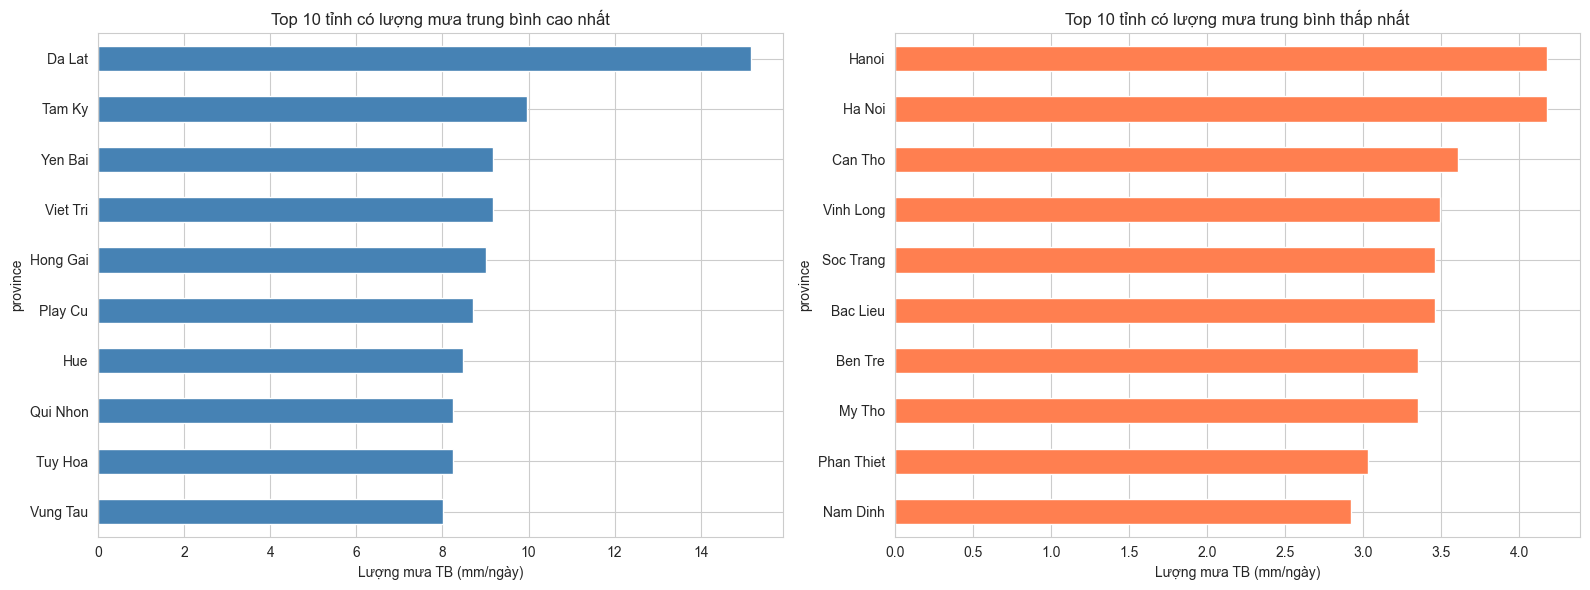



5 Tỉnh có số ngày mưa nhiều nhất:
          Số ngày mưa
province             
Hue              4085
Da Lat           4060
Qui Nhon         3882
Tuy Hoa          3882
Cam Ranh         3881

5 Tỉnh có số ngày mưa ít nhất:
            Số ngày mưa
province               
Tan An             3355
Cam Pha            3348
Vung Tau           3244
Play Cu            3226
Phan Thiet         2784


In [10]:
# Lượng mưa trung bình theo tỉnh
rain_by_province = df.groupby('province')['rain'].agg(['mean', 'sum', 'count']).round(2)
rain_by_province.columns = ['Lượng mưa TB', 'Tổng lượng mưa', 'Số ngày']
rain_by_province = rain_by_province.sort_values('Lượng mưa TB', ascending=False)

print('=' * 70)
print('TỈNH/THÀNH PHỐ CÓ LƯỢNG MƯA CAO NHẤT/THẤP NHẤT')
print('=' * 70)
print('\n5 Tỉnh có lượng mưa TB cao nhất (mm/ngày):')
print(rain_by_province.head())
print('\n5 Tỉnh có lượng mưa TB thấp nhất (mm/ngày):')
print(rain_by_province.tail())

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ top 10 tỉnh có mưa nhiều
rain_by_province.head(10)['Lượng mưa TB'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Lượng mưa TB (mm/ngày)')
axes[0].set_title('Top 10 tỉnh có lượng mưa trung bình cao nhất')
axes[0].invert_yaxis()

# Biểu đồ 10 tỉnh có mưa ít nhất
rain_by_province.tail(10)['Lượng mưa TB'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Lượng mưa TB (mm/ngày)')
axes[1].set_title('Top 10 tỉnh có lượng mưa trung bình thấp nhất')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Số ngày mưa (rain > 0)
rain_days = df[df['rain'] > 0].groupby('province').size().to_frame('Số ngày mưa')
rain_days = rain_days.sort_values('Số ngày mưa', ascending=False)
print('\n\n5 Tỉnh có số ngày mưa nhiều nhất:')
print(rain_days.head())
print('\n5 Tỉnh có số ngày mưa ít nhất:')
print(rain_days.tail())

### Câu 2: Mối liên hệ giữa Nhiệt độ cao nhất và Độ ẩm trong những ngày hè ở Hà Nội và TP.HCM?

MỐI LIÊN HỆ GIỮA NHIỆT ĐỘ CAO NHẤT VÀ ĐỘ ẨM (NGÀY HÈ)

Hà Nội - Mùa hè:
  Số ngày: 1122
  Tương quan (Nhiệt độ-Độ ẩm): -0.812
  Nhiệt độ TB: 34.7°C
  Độ ẩm TB: 75.9%


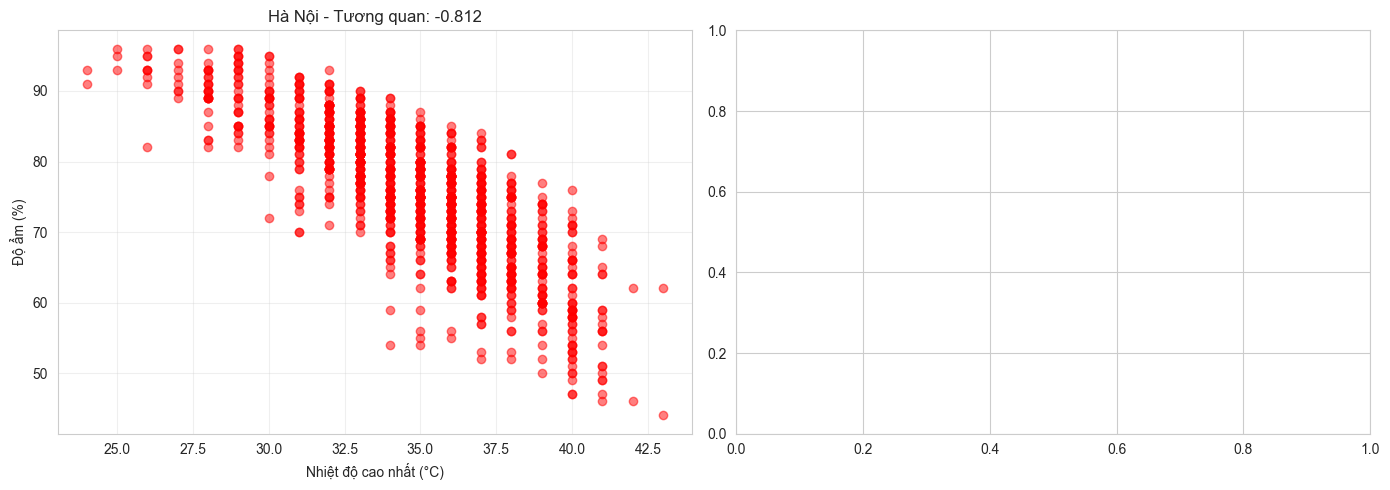

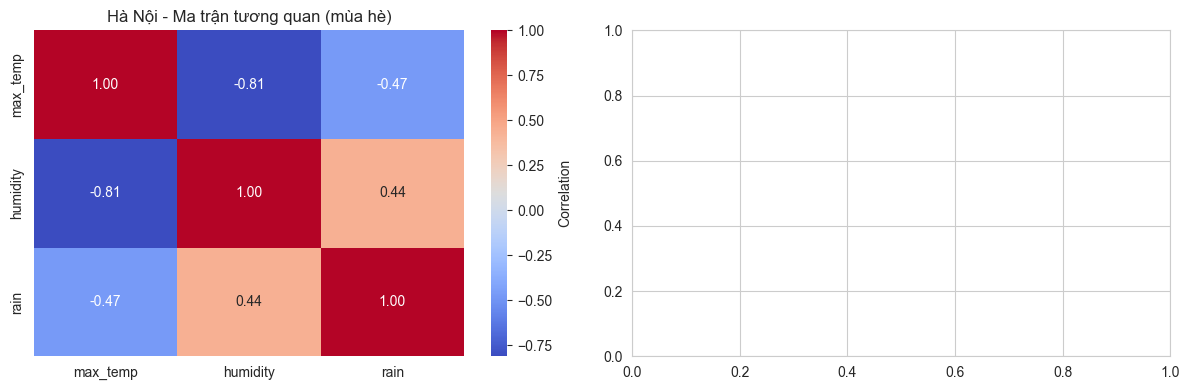

In [ ]:
# Phân tích mối tương quan giữa nhiệt độ và độ ẩm

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Lọc ngày hè
summer_data = df[df['month'].isin([6, 7, 8])]

# Dữ liệu Hà Nội
hanoi_summer = summer_data[summer_data['province'] == 'Ha Noi']

# Dữ liệu TP.HCM
hcm_summer = summer_data[summer_data['province'] == 'Ho Chi Minh']

print('=' * 70)
print('MỐI LIÊN HỆ GIỮA NHIỆT ĐỘ CAO NHẤT VÀ ĐỘ ẨM (NGÀY HÈ)')
print('=' * 70)

# Tính tương quan cho Hà Nội
if len(hanoi_summer) > 0:
    hanoi_corr = hanoi_summer[['max_temp', 'humidity']].corr().iloc[0, 1]
    print(f'\nHà Nội - Mùa hè:')
    print(f'  Số ngày: {len(hanoi_summer)}')
    print(f'  Tương quan (Nhiệt độ-Độ ẩm): {hanoi_corr:.3f}')
    print(f'  Nhiệt độ TB: {hanoi_summer["max_temp"].mean():.1f}°C')
    print(f'  Độ ẩm TB: {hanoi_summer["humidity"].mean():.1f}%')

# Tính tương quan cho TP.HCM
if len(hcm_summer) > 0:
    hcm_corr = hcm_summer[['max_temp', 'humidity']].corr().iloc[0, 1]
    print(f'\nTP.HCM - Mùa hè:')
    print(f'  Số ngày: {len(hcm_summer)}')
    print(f'  Tương quan (Nhiệt độ-Độ ẩm): {hcm_corr:.3f}')
    print(f'  Nhiệt độ TB: {hcm_summer["max_temp"].mean():.1f}°C')
    print(f'  Độ ẩm TB: {hcm_summer["humidity"].mean():.1f}%')

# Vẽ biểu đồ scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(hanoi_summer) > 0:
    axes[0].scatter(hanoi_summer['max_temp'], hanoi_summer['humidity'], alpha=0.5, color='red')
    axes[0].set_xlabel('Nhiệt độ cao nhất (°C)')
    axes[0].set_ylabel('Độ ẩm (%)')
    axes[0].set_title(f'Hà Nội - Tương quan: {hanoi_corr:.3f}')
    axes[0].grid(True, alpha=0.3)

if len(hcm_summer) > 0:
    axes[1].scatter(hcm_summer['max_temp'], hcm_summer['humidity'], alpha=0.5, color='blue')
    axes[1].set_xlabel('Nhiệt độ cao nhất (°C)')
    axes[1].set_ylabel('Độ ẩm (%)')
    axes[1].set_title(f'TP.HCM - Tương quan: {hcm_corr:.3f}')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Heatmap tương quan tổng quát cho cả 2 thành phố
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(hanoi_summer) > 0:
    sns.heatmap(hanoi_summer[['max_temp', 'humidity', 'rain']].corr(), 
                annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar_kws={'label': 'Correlation'})
    axes[0].set_title('Hà Nội - Ma trận tương quan (mùa hè)')

if len(hcm_summer) > 0:
    sns.heatmap(hcm_summer[['max_temp', 'humidity', 'rain']].corr(), 
                annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Correlation'})
    axes[1].set_title('TP.HCM - Ma trận tương quan (mùa hè)')

plt.tight_layout()
plt.show()

### Câu 3: Lượng mưa có xu hướng tập trung vào các tháng nào (Bắc - Trung - Nam)?

XU HƯỚNG MƯA THEO MÙA Ở 3 MIỀN

Lượng mưa trung bình theo tháng (mm/ngày):
region   Khác  Miền Bắc  Miền Nam  Miền Trung
month                                        
1        2.82      1.86      0.98        1.72
2        1.53      1.06      0.43        1.20
3        2.40      1.83      1.07        1.70
4        4.95      3.10      2.64        2.85
5        8.91      7.90      5.47        4.56
6        9.86     11.38      5.44        6.04
7       10.48     13.44      5.49       11.46
8       11.44     14.46      6.08       14.08
9       12.52     10.77      6.70       12.36
10      11.29      5.01      7.16        9.89
11       9.05      1.89      3.98        3.55
12       4.57      1.31      1.85        1.81


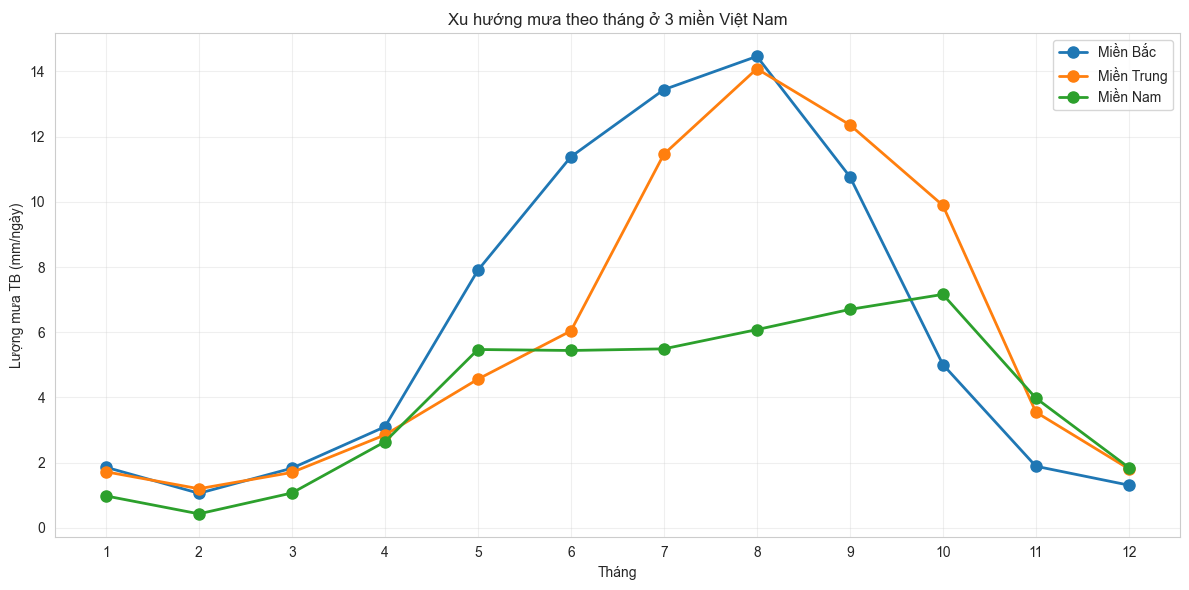

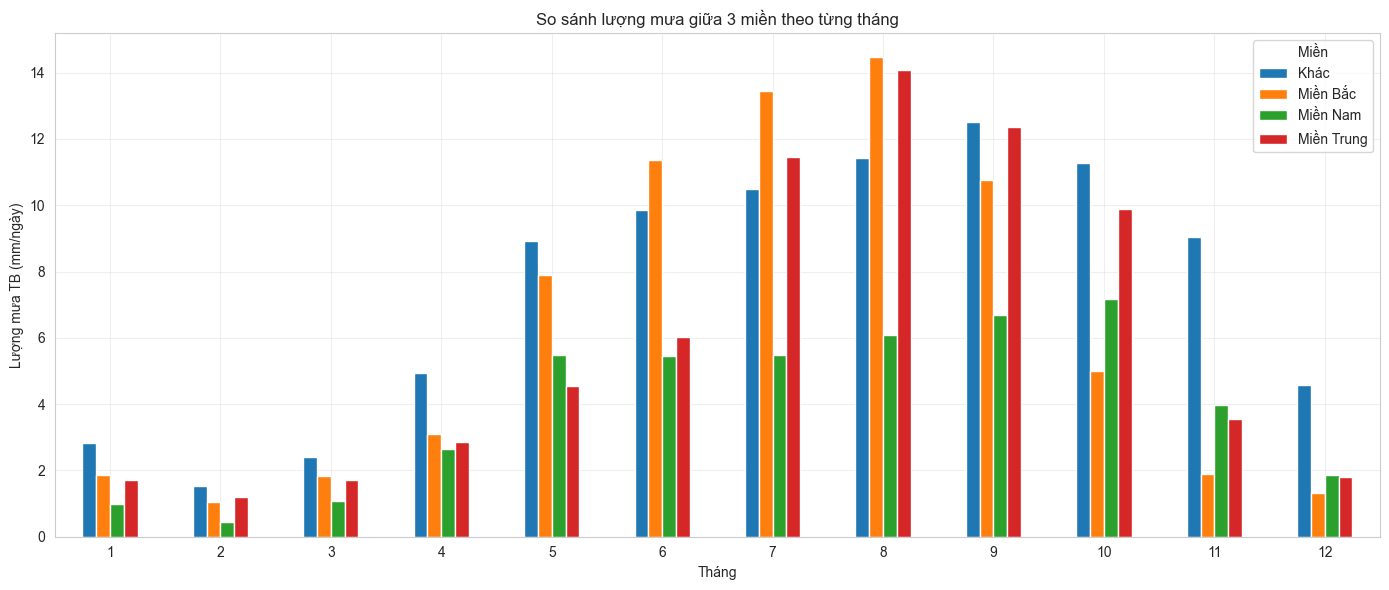


Mùa mưa của từng miền:
Miền Bắc: Tháng 5, 6, 7, 8, 9, 10
Miền Trung: Tháng 5, 6, 7, 8, 9, 10
Miền Nam: Tháng 5, 6, 7, 8, 9, 10


In [12]:
# Phân tích xu hướng mưa theo mùa ở 3 miền Bắc - Trung - Nam

# Định nghĩa 3 miền Việt Nam
northern_provinces = ['Ha Noi', 'Ha Giang', 'Cao Bang', 'Bac Kan', 'Tuyên Quang', 'Lao Cai', 
                     'Yen Bai', 'Thai Nguyen', 'Lang Son', 'Quang Ninh', 'Bac Giang', 'Bac Ninh', 
                     'Hai Duong', 'Hai Phong', 'Hung Yen', 'Thai Binh', 'Ha Nam', 'Nam Dinh', 
                     'Ninh Binh']

central_provinces = ['Thanh Hoa', 'Nghe An', 'Ha Tinh', 'Quang Binh', 'Quang Tri', 'Thua Thien - Hue', 
                    'Da Nang', 'Quang Nam', 'Quang Ngai', 'Binh Dinh', 'Phu Yen', 'Khanh Hoa']

southern_provinces = ['Ninh Thuan', 'Binh Thuan', 'Ba Ria - Vung Tau', 'Ho Chi Minh', 'Dong Nai', 
                     'Binh Duong', 'Binh Phuoc', 'Tay Ninh', 'An Giang', 'Dong Thap', 'Kien Giang', 
                     'Can Tho', 'Vinh Long', 'Tra Vinh', 'Ben Tre', 'Ca Mau', 'Bac Lieu', 'Soc Trang']

# Gán miền cho mỗi tỉnh
def assign_region(province):
    if province in northern_provinces:
        return 'Miền Bắc'
    elif province in central_provinces:
        return 'Miền Trung'
    elif province in southern_provinces:
        return 'Miền Nam'
    else:
        return 'Khác'

df['region'] = df['province'].apply(assign_region)

print('=' * 70)
print('XU HƯỚNG MƯA THEO MÙA Ở 3 MIỀN')
print('=' * 70)

# Tính lượng mưa TB theo tháng và miền
rain_by_month_region = df.groupby(['month', 'region'])['rain'].mean().round(2)
rain_by_month_region = rain_by_month_region.unstack(fill_value=0)

print('\nLượng mưa trung bình theo tháng (mm/ngày):')
print(rain_by_month_region)

# Vẽ biểu đồ line plot
plt.figure(figsize=(12, 6))
for region in ['Miền Bắc', 'Miền Trung', 'Miền Nam']:
    if region in rain_by_month_region.columns:
        plt.plot(rain_by_month_region.index, rain_by_month_region[region], 
                marker='o', label=region, linewidth=2, markersize=8)

plt.xlabel('Tháng')
plt.ylabel('Lượng mưa TB (mm/ngày)')
plt.title('Xu hướng mưa theo tháng ở 3 miền Việt Nam')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Vẽ biểu đồ bar plot so sánh
rain_by_month_region.plot(kind='bar', figsize=(14, 6))
plt.xlabel('Tháng')
plt.ylabel('Lượng mưa TB (mm/ngày)')
plt.title('So sánh lượng mưa giữa 3 miền theo từng tháng')
plt.xticks(rotation=0)
plt.legend(title='Miền')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Xác định mùa mưa cho mỗi miền
print('\nMùa mưa của từng miền:')
for region in ['Miền Bắc', 'Miền Trung', 'Miền Nam']:
    if region in rain_by_month_region.columns:
        rain_months = rain_by_month_region[region][rain_by_month_region[region] > rain_by_month_region[region].median()].index.tolist()
        print(f'{region}: Tháng {", ".join(map(str, sorted(rain_months)))}')

### Câu 4: Tốc độ gió và hướng gió có tác động đến lượng mưa ở tỉnh ven biển?

ẢNH HƯỞNG GIÓ ĐẾN LƯỢNG MƯA Ở TỈN VEN BIỂN

Tương quan tổng thể (Tốc độ gió - Lượng mưa): -0.074
Số tỉnh ven biển: 5

Tương quan theo từng tỉnh ven biển:
province
Thanh Hoa    0.124
Nam Dinh     0.065
Ca Mau      -0.157
Bac Lieu    -0.269
Soc Trang   -0.269
dtype: float64


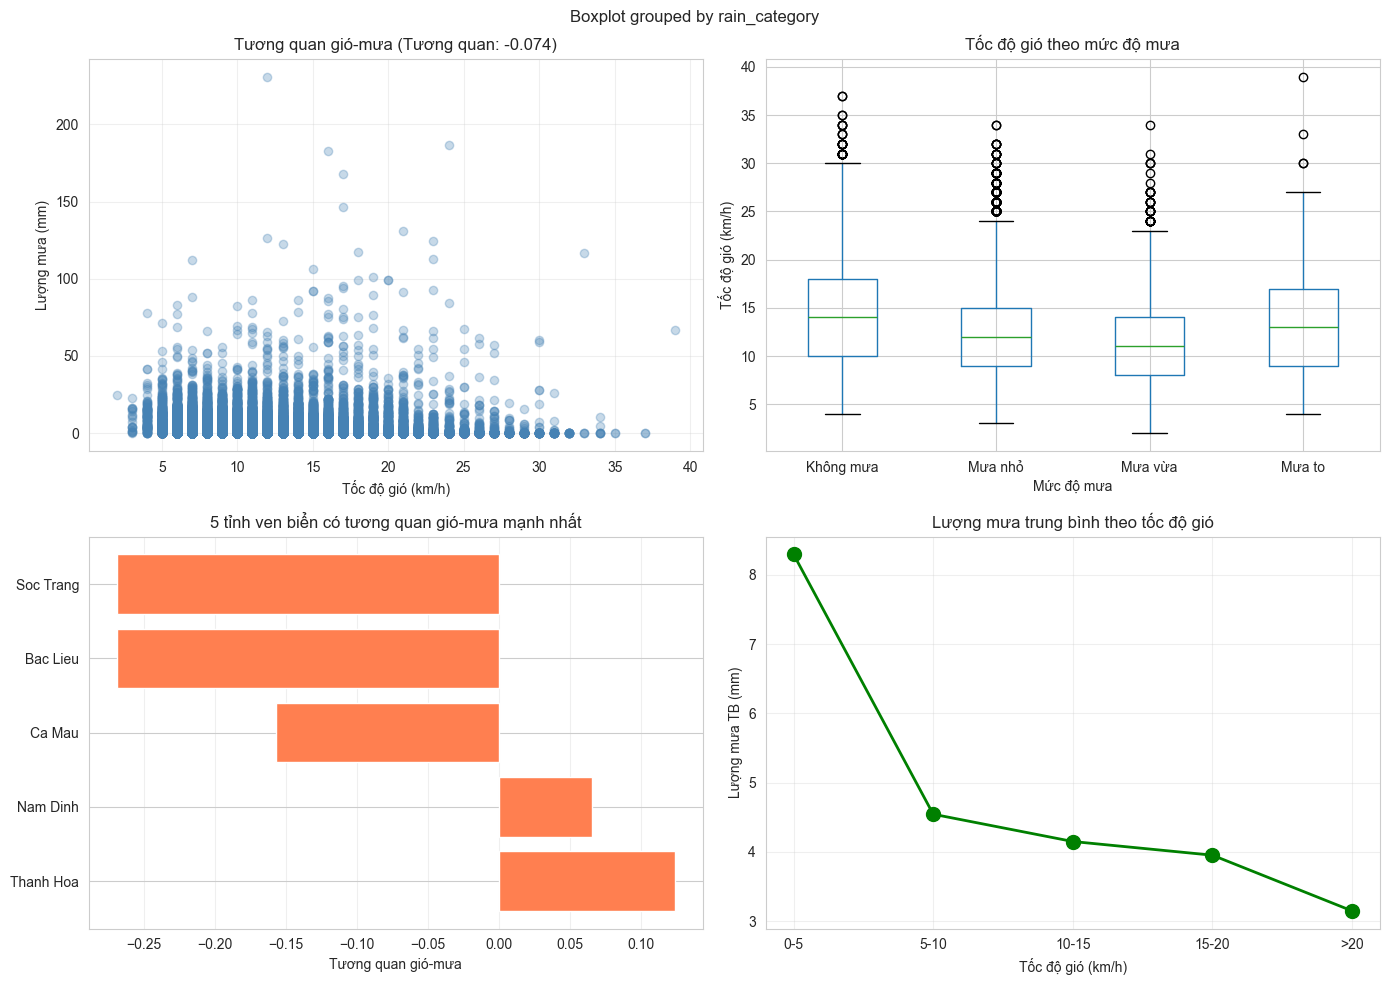

In [13]:
# Phân tích tương quan giữa gió và mưa ở tỉnh ven biển

# Định nghĩa các tỉnh ven biển
coastal_provinces = ['Ha Phong', 'Quang Ninh', 'Thai Binh', 'Nam Dinh', 'Thanh Hoa', 
                    'Nghe An', 'Ha Tinh', 'Quang Binh', 'Quang Tri', 'Da Nang', 'Quang Nam', 
                    'Quang Ngai', 'Binh Dinh', 'Phu Yen', 'Khanh Hoa', 'Ninh Thuan', 
                    'Binh Thuan', 'Ba Ria - Vung Tau', 'Ca Mau', 'Bac Lieu', 'Soc Trang', 
                    'Kien Giang', 'Ho Chi Minh']

df_coastal = df[df['province'].isin(coastal_provinces)].copy()

print('=' * 70)
print('ẢNH HƯỞNG GIÓ ĐẾN LƯỢNG MƯA Ở TỈN VEN BIỂN')
print('=' * 70)

# Tính tương quan toàn bộ
wind_rain_corr = df_coastal[['wind_speed', 'rain']].corr().iloc[0, 1]
print(f'\nTương quan tổng thể (Tốc độ gió - Lượng mưa): {wind_rain_corr:.3f}')
print(f'Số tỉnh ven biển: {df_coastal["province"].nunique()}')

# Tương quan theo từng tỉnh ven biển
print('\nTương quan theo từng tỉnh ven biển:')
coastal_corr = df_coastal.groupby('province').apply(
    lambda x: x[['wind_speed', 'rain']].corr().iloc[0, 1] if len(x) > 1 else np.nan
).sort_values(ascending=False)

print(coastal_corr.round(3))

# Vẽ biểu đồ scatter plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot tổng quát
axes[0, 0].scatter(df_coastal['wind_speed'], df_coastal['rain'], alpha=0.3, color='steelblue')
axes[0, 0].set_xlabel('Tốc độ gió (km/h)')
axes[0, 0].set_ylabel('Lượng mưa (mm)')
axes[0, 0].set_title(f'Tương quan gió-mưa (Tương quan: {wind_rain_corr:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# Boxplot tốc độ gió theo mức độ mưa
df_coastal['rain_category'] = pd.cut(df_coastal['rain'], 
                                     bins=[-np.inf, 0, 10, 30, np.inf],
                                     labels=['Không mưa', 'Mưa nhỏ', 'Mưa vừa', 'Mưa to'])
df_coastal.boxplot(column='wind_speed', by='rain_category', ax=axes[0, 1])
axes[0, 1].set_xlabel('Mức độ mưa')
axes[0, 1].set_ylabel('Tốc độ gió (km/h)')
axes[0, 1].set_title('Tốc độ gió theo mức độ mưa')

# Biểu đồ bar so sánh 5 tỉnh ven biển có tương quan mạnh nhất
top_5_coastal = coastal_corr.head(5)
axes[1, 0].barh(range(len(top_5_coastal)), top_5_coastal.values, color='coral')
axes[1, 0].set_yticks(range(len(top_5_coastal)))
axes[1, 0].set_yticklabels(top_5_coastal.index)
axes[1, 0].set_xlabel('Tương quan gió-mưa')
axes[1, 0].set_title('5 tỉnh ven biển có tương quan gió-mưa mạnh nhất')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Lượng mưa TB theo tốc độ gió
wind_speed_bins = pd.cut(df_coastal['wind_speed'], bins=[0, 5, 10, 15, 20, np.inf],
                         labels=['0-5', '5-10', '10-15', '15-20', '>20'])
rain_by_wind = df_coastal.groupby(wind_speed_bins)['rain'].mean()
axes[1, 1].plot(range(len(rain_by_wind)), rain_by_wind.values, marker='o', linewidth=2, markersize=10, color='green')
axes[1, 1].set_xticks(range(len(rain_by_wind)))
axes[1, 1].set_xticklabels(rain_by_wind.index)
axes[1, 1].set_xlabel('Tốc độ gió (km/h)')
axes[1, 1].set_ylabel('Lượng mưa TB (mm)')
axes[1, 1].set_title('Lượng mưa trung bình theo tốc độ gió')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Câu 5: Xu hướng biến đổi nhiệt độ trung bình của Việt Nam trong 10 năm qua?

XU HƯỚNG BIẾN ĐỔI NHIỆT ĐỘ CỦA VIỆT NAM (2009-2021)

Nhiệt độ trung bình theo năm (°C):
      max_temp  min_temp  avg_temp  avg_annual_temp
year                                               
2009     29.01     22.87     25.94            25.94
2010     30.08     23.28     26.68            26.68
2011     28.98     22.39     25.68            25.68
2012     29.85     23.37     26.61            26.61
2013     29.95     23.22     26.59            26.59
2014     30.08     23.15     26.62            26.62
2015     30.35     23.68     27.01            27.01
2016     30.23     23.59     26.91            26.91
2017     29.78     23.41     26.59            26.59
2018     30.09     23.60     26.85            26.85
2019     30.29     23.81     27.05            27.05
2020     29.68     23.39     26.53            26.53
2021     29.15     22.38     25.76            25.76

Xu hướng tăng nhiệt độ:
  Slope (độ tăng/năm): 0.0256°C/năm
  Hệ số tương quan (R²): 0.049
  P-value: 0.4692 (Có ý nghĩa thống kê: 

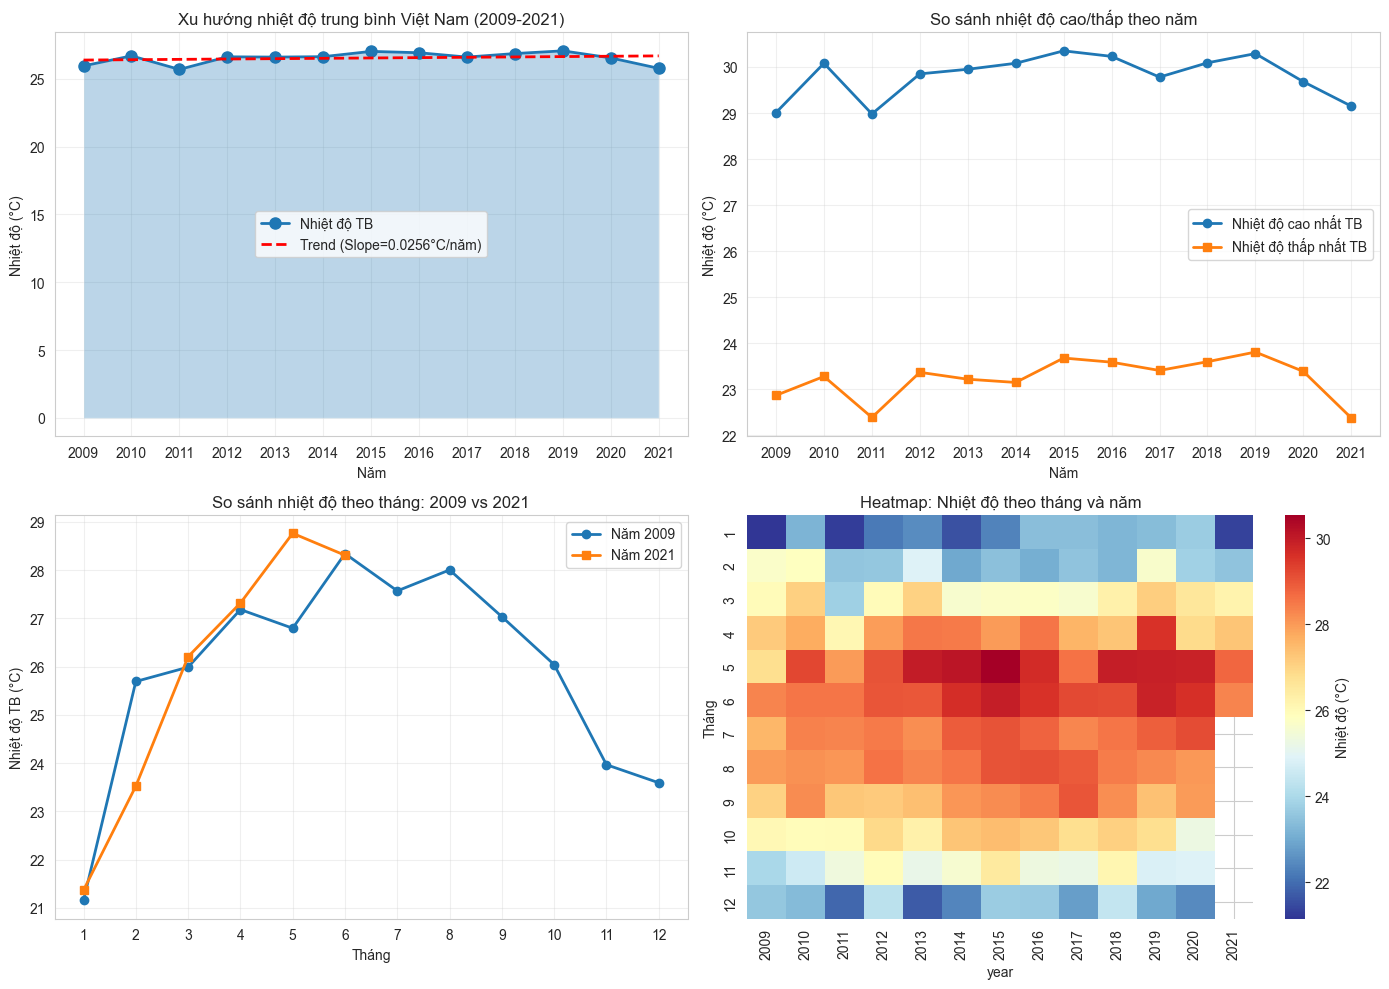

In [14]:
# Phân tích xu hướng tăng nhiệt độ theo thời gian

df['year'] = df['date'].dt.year
# Tính avg_temp từ max_temp và min_temp
df['avg_temp'] = ((df['max_temp'] + df['min_temp']) / 2).round(2)

print('=' * 70)
print('XU HƯỚNG BIẾN ĐỔI NHIỆT ĐỘ CỦA VIỆT NAM (2009-2021)')
print('=' * 70)

# Tính nhiệt độ TB theo năm
temp_by_year = df.groupby('year')[['max_temp', 'min_temp', 'avg_temp']].mean().round(2)
temp_by_year['avg_annual_temp'] = temp_by_year['avg_temp']

print('\nNhiệt độ trung bình theo năm (°C):')
print(temp_by_year)

# Tính xu hướng (slope)
from scipy import stats
x = np.arange(len(temp_by_year))
slope, intercept, r_value, p_value, std_err = stats.linregress(x, temp_by_year['avg_annual_temp'].values)

print(f'\nXu hướng tăng nhiệt độ:')
print(f'  Slope (độ tăng/năm): {slope:.4f}°C/năm')
print(f'  Hệ số tương quan (R²): {r_value**2:.3f}')
print(f'  P-value: {p_value:.4f} (Có ý nghĩa thống kê: {p_value < 0.05})')
print(f'  Tổng tăng (2009-2021): {slope * (len(temp_by_year) - 1):.2f}°C')

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Line plot nhiệt độ trung bình theo năm
axes[0, 0].plot(temp_by_year.index, temp_by_year['avg_annual_temp'], marker='o', linewidth=2, markersize=8, label='Nhiệt độ TB')
axes[0, 0].plot(temp_by_year.index, intercept + slope * x, 'r--', linewidth=2, label=f'Trend (Slope={slope:.4f}°C/năm)')
axes[0, 0].fill_between(temp_by_year.index, temp_by_year['avg_annual_temp'], alpha=0.3)
axes[0, 0].set_xlabel('Năm')
axes[0, 0].set_ylabel('Nhiệt độ (°C)')
axes[0, 0].set_title('Xu hướng nhiệt độ trung bình Việt Nam (2009-2021)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(temp_by_year.index)

# So sánh nhiệt độ cao/thấp
axes[0, 1].plot(temp_by_year.index, temp_by_year['max_temp'], marker='o', label='Nhiệt độ cao nhất TB', linewidth=2)
axes[0, 1].plot(temp_by_year.index, temp_by_year['min_temp'], marker='s', label='Nhiệt độ thấp nhất TB', linewidth=2)
axes[0, 1].set_xlabel('Năm')
axes[0, 1].set_ylabel('Nhiệt độ (°C)')
axes[0, 1].set_title('So sánh nhiệt độ cao/thấp theo năm')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(temp_by_year.index)

# Nhiệt độ trung bình theo tháng (so sánh năm đầu vs năm cuối)
first_year = df[df['year'] == df['year'].min()]
last_year = df[df['year'] == df['year'].max()]

temp_by_month_first = first_year.groupby('month')['avg_temp'].mean()
temp_by_month_last = last_year.groupby('month')['avg_temp'].mean()

axes[1, 0].plot(temp_by_month_first.index, temp_by_month_first.values, marker='o', label=f'Năm {df["year"].min()}', linewidth=2)
axes[1, 0].plot(temp_by_month_last.index, temp_by_month_last.values, marker='s', label=f'Năm {df["year"].max()}', linewidth=2)
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('Nhiệt độ TB (°C)')
axes[1, 0].set_title(f'So sánh nhiệt độ theo tháng: {df["year"].min()} vs {df["year"].max()}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(1, 13))

# Heatmap: Nhiệt độ theo năm-tháng
pivot_temp = df.pivot_table(values='avg_temp', index='month', columns='year', aggfunc='mean')
sns.heatmap(pivot_temp, cmap='RdYlBu_r', ax=axes[1, 1], cbar_kws={'label': 'Nhiệt độ (°C)'})
axes[1, 1].set_ylabel('Tháng')
axes[1, 1].set_title('Heatmap: Nhiệt độ theo tháng và năm')

plt.tight_layout()
plt.show()

## 2. BÀI TOÁN PHÂN LỚP (CLASSIFICATION) - Dự Báo Mức Độ Mưa

**Mục tiêu:** Dự báo mức độ mưa (Không mưa, Mưa nhỏ, Mưa vừa, Mưa to) dựa trên dữ liệu thời tiết hiện tại

**Thuật toán:** Logistic Regression, Random Forest, Decision Tree

CHUẨN BỊ DỮ LIỆU CHO CLASSIFICATION

Phân phối mức độ mưa:
rain_level
Không mưa    48308
Mưa nhỏ      98061
Mưa vừa      27763
Mưa to        7828
Name: count, dtype: int64

Tỷ lệ %:
rain_level
Không mưa    26.548692
Mưa nhỏ      53.891515
Mưa vừa      15.257749
Mưa to        4.302044
Name: proportion, dtype: float64


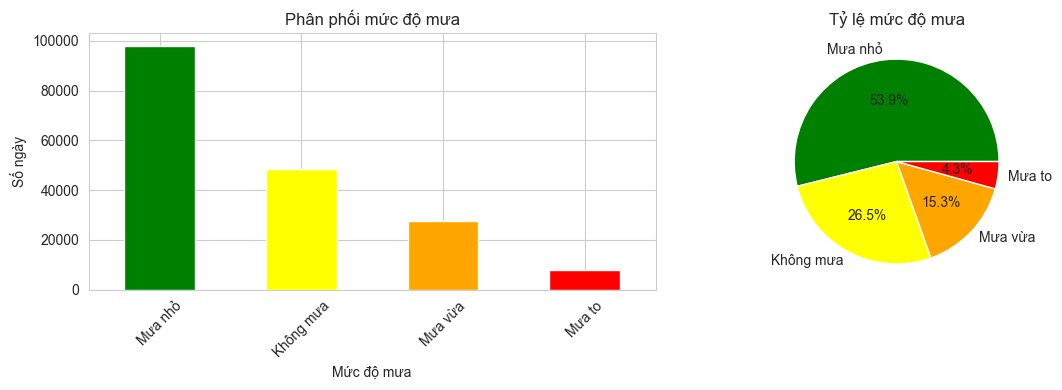


✓ Target variable (rain_level) đã được tạo!


In [ ]:
# Chuẩn bị dữ liệu cho Classification

# 1. Xây dựng target variable (Mức độ mưa)
print('=' * 70)
print('CHUẨN BỊ DỮ LIỆU CHO CLASSIFICATION')
print('=' * 70)

# Tạo biến target: Phân loại mức độ mưa
df['rain_level'] = pd.cut(df['rain'], 
                          bins=[-np.inf, 0.1, 10, 30, np.inf], 
                          labels=['Không mưa', 'Mưa nhỏ', 'Mưa vừa', 'Mưa to'])

print('\nPhân phối mức độ mưa:')
print(df['rain_level'].value_counts().sort_index())
print('\nTỷ lệ %:')
print(df['rain_level'].value_counts(normalize=True).sort_index() * 100)

# Vẽ biểu đồ phân phối target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rain_level'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'yellow', 'orange', 'red'])
axes[0].set_title('Phân phối mức độ mưa')
axes[0].set_ylabel('Số ngày')
axes[0].set_xlabel('Mức độ mưa')
axes[0].tick_params(axis='x', rotation=45)

df['rain_level'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
                                                    colors=['green', 'yellow', 'orange', 'red'],
                                                    autopct='%1.1f%%')
axes[1].set_title('Tỷ lệ mức độ mưa')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\n✓ Target variable (rain_level) đã được tạo!')

In [ ]:
# 2. Chuẩn bị features

# - Chọn các cột cần thiết
# - Xử lý missing values
# - Chuẩn hóa dữ liệu (StandardScaler)
# - Chia train/test set (80/20)
print('=' * 70)
print('CHUẨN BỊ FEATURES CHO MÔ HÌNH')
print('=' * 70)

# Chọn các features phù hợp
feature_cols = ['max_temp', 'min_temp', 'humidity', 'wind_speed', 
                'cloud_cover', 'pressure']

# Tạo bản sao dữ liệu để làm sạch
df_model = df.copy()

# Xử lý missing values - Điền giá trị trung bình
print('\nXử lý missing values:')
for col in feature_cols:
    if col in df_model.columns:
        missing_count = df_model[col].isnull().sum()
        if missing_count > 0:
            print(f'  {col}: {missing_count} missing values → Điền bằng trung bình')
            df_model[col].fillna(df_model[col].mean(), inplace=True)

# Loại bỏ hàng có target label bị missing
df_model = df_model.dropna(subset=['rain_level'])
print(f'\nSau khi xử lý: {len(df_model)} hàng dữ liệu')

# Tách features (X) và target (y)
X = df_model[feature_cols]
y = df_model['rain_level']

# Encode target variable (chuyển label thành số)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f'\nEncoding target:')
for i, label in enumerate(label_encoder.classes_):
    print(f'  {i}: {label}')

# Chia train/test set (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, 
                                                      random_state=42, stratify=y_encoded)

print(f'\nChia dữ liệu:')
print(f'  Train set: {len(X_train)} mẫu ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test set: {len(X_test)} mẫu ({len(X_test)/len(X)*100:.1f}%)')

# Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n✓ Dữ liệu đã được chuẩn hóa!')
print(f'  Thống kê X_train_scaled:')
print(f'    Mean: {X_train_scaled.mean(axis=0).round(3)}')
print(f'    Std: {X_train_scaled.std(axis=0).round(3)}')

CHUẨN BỊ FEATURES CHO MÔ HÌNH

Xử lý missing values:

Sau khi xử lý: 181960 hàng dữ liệu

Encoding target:
  0: Không mưa
  1: Mưa nhỏ
  2: Mưa to
  3: Mưa vừa

Chia dữ liệu:
  Train set: 145568 mẫu (80.0%)
  Test set: 36392 mẫu (20.0%)

✓ Dữ liệu đã được chuẩn hóa!
  Thống kê X_train_scaled:
    Mean: [ 0.  0.  0.  0.  0. -0.]
    Std: [1. 1. 1. 1. 1. 1.]


In [ ]:
# 3. Huấn luyện các mô hình

# - Logistic Regression
# - Random Forest
# - Decision Tree
print('=' * 70)
print('HUẤN LUYỆN CÁC MÔ HÌNH CLASSIFICATION')
print('=' * 70)

# Dictionary để lưu các mô hình
models = {}

# 1. Logistic Regression
print('\n[1] Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
print('✓ Logistic Regression đã được huấn luyện')

# 2. Random Forest
print('\n[2] Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
print('✓ Random Forest đã được huấn luyện')

# Hiển thị feature importance
print('\n  Feature Importance (Random Forest):')
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.to_string(index=False))

# 3. Decision Tree
print('\n[3] Decision Tree...')
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt_model
print('✓ Decision Tree đã được huấn luyện')

print('\n✓ Tất cả mô hình đã được huấn luyện xong!')

HUẤN LUYỆN CÁC MÔ HÌNH CLASSIFICATION

[1] Logistic Regression...
✓ Logistic Regression đã được huấn luyện

[2] Random Forest...
✓ Random Forest đã được huấn luyện

  Feature Importance (Random Forest):
    Feature  Importance
cloud_cover    0.297206
   humidity    0.210236
 wind_speed    0.154098
   pressure    0.130042
   max_temp    0.104502
   min_temp    0.103915

[3] Decision Tree...
✓ Decision Tree đã được huấn luyện

✓ Tất cả mô hình đã được huấn luyện xong!


ĐÁNH GIÁ CÁC MÔ HÌNH

Logistic Regression:
  Train Accuracy: 0.6736
  Test Accuracy: 0.6757

Random Forest:
  Train Accuracy: 0.9968
  Test Accuracy: 0.7715

Decision Tree:
  Train Accuracy: 0.7751
  Test Accuracy: 0.6948


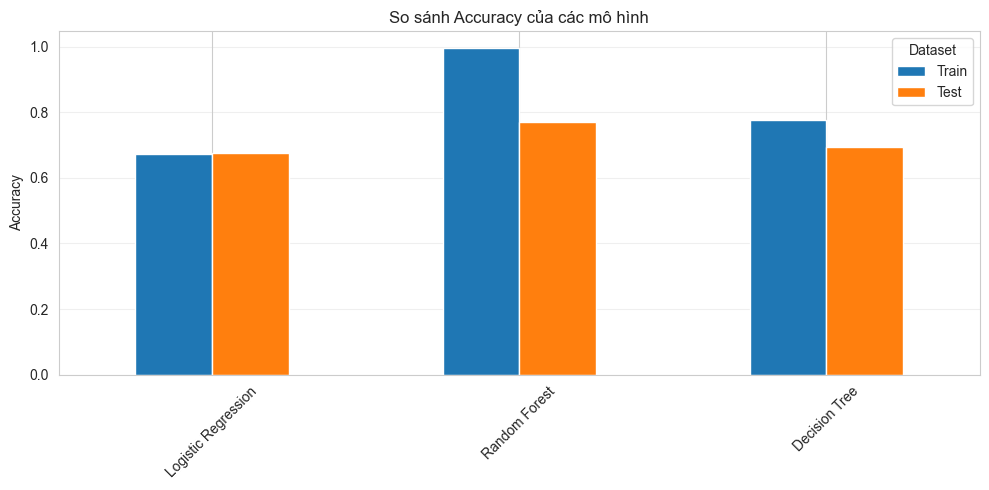


CONFUSION MATRIX VÀ CLASSIFICATION REPORT


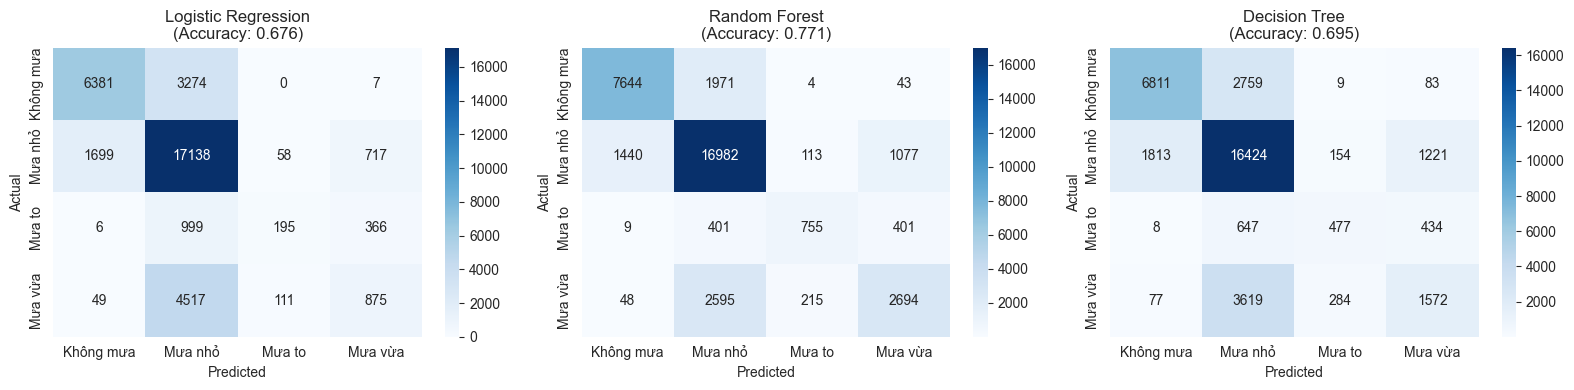




Logistic Regression:
              precision    recall  f1-score   support

   Không mưa       0.78      0.66      0.72      9662
     Mưa nhỏ       0.66      0.87      0.75     19612
      Mưa to       0.54      0.12      0.20      1566
     Mưa vừa       0.45      0.16      0.23      5552

    accuracy                           0.68     36392
   macro avg       0.61      0.45      0.48     36392
weighted avg       0.66      0.68      0.64     36392


Random Forest:
              precision    recall  f1-score   support

   Không mưa       0.84      0.79      0.81      9662
     Mưa nhỏ       0.77      0.87      0.82     19612
      Mưa to       0.69      0.48      0.57      1566
     Mưa vừa       0.64      0.49      0.55      5552

    accuracy                           0.77     36392
   macro avg       0.74      0.66      0.69     36392
weighted avg       0.77      0.77      0.76     36392


Decision Tree:
              precision    recall  f1-score   support

   Không mưa       

In [ ]:
# 4. Đánh giá mô hình

# - Accuracy
# - Confusion Matrix
# - Classification Report
print('=' * 70)
print('ĐÁNH GIÁ CÁC MÔ HÌNH')
print('=' * 70)

# Tính accuracy cho tất cả mô hình
results = {}
for model_name, model in models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results[model_name] = {'Train': train_acc, 'Test': test_acc}
    
    print(f'\n{model_name}:')
    print(f'  Train Accuracy: {train_acc:.4f}')
    print(f'  Test Accuracy: {test_acc:.4f}')

# Vẽ biểu đồ so sánh Accuracy
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10, 5), rot=45)
plt.ylabel('Accuracy')
plt.title('So sánh Accuracy của các mô hình')
plt.legend(title='Dataset')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Chi tiết cho mỗi mô hình
print('\n' + '=' * 70)
print('CONFUSION MATRIX VÀ CLASSIFICATION REPORT')
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    axes[idx].set_title(f'{model_name}\n(Accuracy: {model.score(X_test_scaled, y_test):.3f})')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Classification Report
print('\n')
for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f'\n{model_name}:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Chọn mô hình tốt nhất
best_model_name = max(results, key=lambda x: results[x]['Test'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['Test']

print('=' * 70)
print(f'✓ MÔ HÌNH TỐT NHẤT: {best_model_name}')
print(f'✓ TEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)')
print('=' * 70)

## 3. BÀI TOÁN PHÂN CỤM (CLUSTERING) - Phân Loại Kiểu Thời Tiết

**Mục tiêu:** Phân loại các ngày thành kiểu hình thời tiết đặc trưng (khô hanh, nồm ẩm, bão tố...)

**Thuật toán:** K-Means Clustering

In [ ]:
# 1. Chuẩn bị dữ liệu cho Clustering

# - Chọn các features phù hợp
# - Xử lý missing values
# - Chuẩn hóa dữ liệu (StandardScaler)
print('=' * 70)
print('CHUẨN BỊ DỮ LIỆU CHO CLUSTERING')
print('=' * 70)

# Chọn features cho clustering (những chỉ số thời tiết chính)
cluster_features = ['max_temp', 'min_temp', 'humidity', 'rain', 'wind_speed', 'pressure']

# Tạo bản sao dữ liệu
df_cluster = df.copy()

# Xử lý missing values
print('\nXử lý missing values:')
for col in cluster_features:
    if col in df_cluster.columns:
        missing_count = df_cluster[col].isnull().sum()
        if missing_count > 0:
            print(f'  {col}: {missing_count} missing values → Điền bằng trung bình')
            df_cluster[col].fillna(df_cluster[col].mean(), inplace=True)

# Loại bỏ hàng có missing values
df_cluster = df_cluster.dropna(subset=cluster_features)
print(f'\nSau xử lý: {len(df_cluster)} hàng dữ liệu')

# Tách features
X_cluster = df_cluster[cluster_features].copy()

# Chuẩn hóa dữ liệu (StandardScaler)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f'\n✓ Dữ liệu đã được chuẩn hóa!')
print(f'  Shape: {X_cluster_scaled.shape}')
print(f'  Thống kê:')
print(f'    Mean: {X_cluster_scaled.mean(axis=0).round(3)}')
print(f'    Std: {X_cluster_scaled.std(axis=0).round(3)}')

CHUẨN BỊ DỮ LIỆU CHO CLUSTERING

Xử lý missing values:

Sau xử lý: 181960 hàng dữ liệu

✓ Dữ liệu đã được chuẩn hóa!
  Shape: (181960, 6)
  Thống kê:
    Mean: [-0. -0.  0.  0. -0. -0.]
    Std: [1. 1. 1. 1. 1. 1.]


XÁC ĐỊNH SỐ CLUSTER TỐI ƯU

Tính inertia và silhouette score cho các giá trị K:
  K=2: Inertia=789588.11, Silhouette=0.325
  K=3: Inertia=664362.07, Silhouette=0.219
  K=4: Inertia=581528.84, Silhouette=0.215
  K=5: Inertia=508983.96, Silhouette=0.221
  K=6: Inertia=452680.34, Silhouette=0.218
  K=7: Inertia=422261.22, Silhouette=0.217
  K=8: Inertia=395807.23, Silhouette=0.212
  K=9: Inertia=373116.98, Silhouette=0.194
  K=10: Inertia=352380.89, Silhouette=0.198


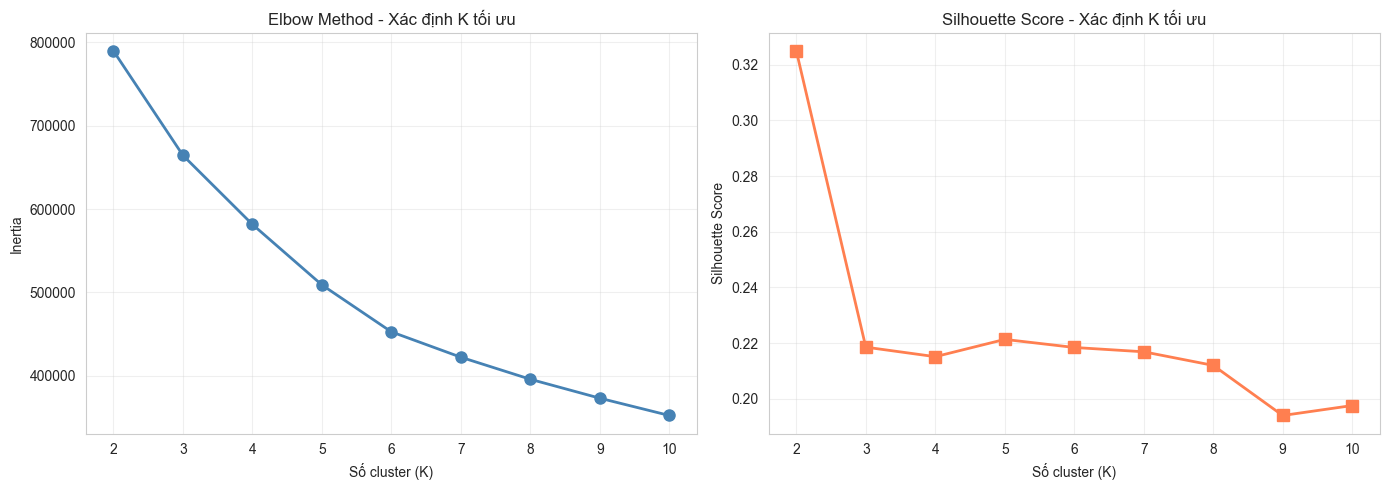


✓ Số cluster tối ưu (dựa trên Silhouette Score): K = 2


In [23]:
# 2. Xác định số cluster tối ưu (Elbow Method & Silhouette Score)

print('=' * 70)
print('XÁC ĐỊNH SỐ CLUSTER TỐI ƯU')
print('=' * 70)

# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print('\nTính inertia và silhouette score cho các giá trị K:')
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_cluster_scaled, kmeans.labels_, sample_size=10000, random_state=42)
    silhouette_scores.append(sil_score)
    print(f'  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}')

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Số cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - Xác định K tối ưu')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Số cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Xác định K tối ưu')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

# Chọn K tối ưu (dựa trên silhouette score cao nhất)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'\n✓ Số cluster tối ưu (dựa trên Silhouette Score): K = {optimal_k}')

HUẤN LUYỆN K-MEANS CLUSTERING

Huấn luyện K-Means với K = 2
✓ Mô hình đã được huấn luyện!

Phân phối các cluster:
cluster
0     47762
1    134198
Name: count, dtype: int64


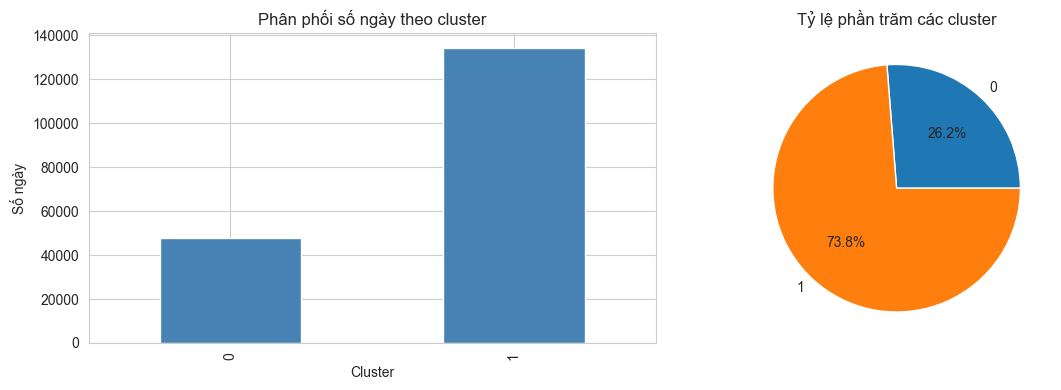

In [24]:
# 3. Huấn luyện K-Means với K tối ưu

print('=' * 70)
print('HUẤN LUYỆN K-MEANS CLUSTERING')
print('=' * 70)

# Huấn luyện K-Means với K tối ưu
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X_cluster_scaled)

# Thêm cluster labels vào dataframe
df_cluster['cluster'] = cluster_labels

print(f'\nHuấn luyện K-Means với K = {optimal_k}')
print(f'✓ Mô hình đã được huấn luyện!')

# Phân phối các cluster
print(f'\nPhân phối các cluster:')
print(df_cluster['cluster'].value_counts().sort_index())

# Vẽ phân phối
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_cluster['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối số ngày theo cluster')
axes[0].set_ylabel('Số ngày')
axes[0].set_xlabel('Cluster')

df_cluster['cluster'].value_counts(normalize=True).sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Tỷ lệ phần trăm các cluster')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

PHÂN TÍCH CHI TIẾT CÁC CLUSTER

Silhouette Score: 0.325

Đặc điểm chi tiết của từng cluster:
         max_temp  min_temp  humidity  rain  wind_speed  pressure
cluster                                                          
0           24.11     18.08     79.43  4.83       10.35   1015.44
1           31.88     25.13     76.25  7.18       11.28   1008.37


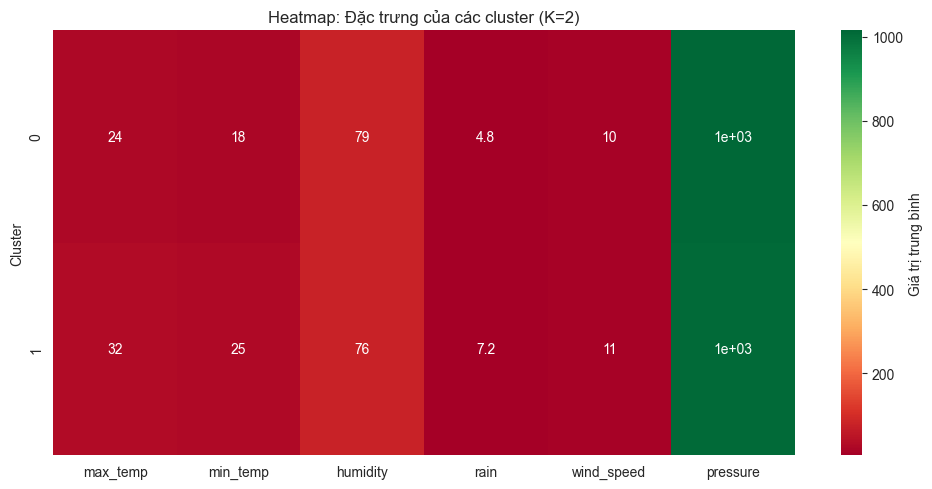


PHÂN LOẠI KIỂU THỜI TIẾT CHO MỖI CLUSTER

Cluster 0:
  Số ngày: 47762
  Nhiệt độ TB: 24.1°C
  Độ ẩm TB: 79.4%
  Lượng mưa TB: 4.8 mm
  Tốc độ gió TB: 10.4 km/h
  Kiểu thời tiết: 🌤️ NGÀY BÌNH THƯỜNG

Cluster 1:
  Số ngày: 134198
  Nhiệt độ TB: 31.9°C
  Độ ẩm TB: 76.2%
  Lượng mưa TB: 7.2 mm
  Tốc độ gió TB: 11.3 km/h
  Kiểu thời tiết: 🌧️ NÓNG NỒNG ẨM


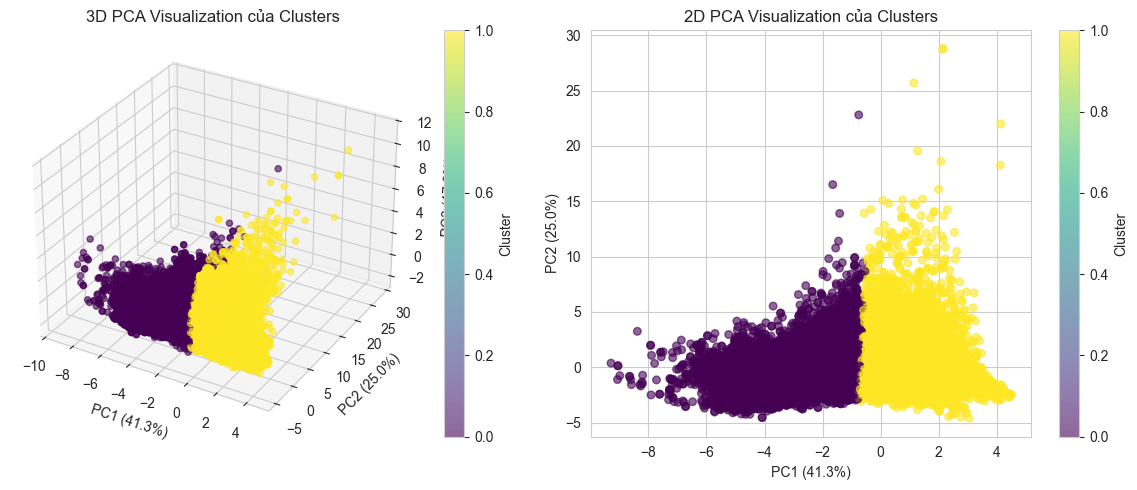


✓ Phân tích clustering đã hoàn thành!


In [26]:
# 4. Phân tích kết quả Clustering

print('=' * 70)
print('PHÂN TÍCH CHI TIẾT CÁC CLUSTER')
print('=' * 70)

# Silhouette Score
sil_score_optimal = silhouette_score(X_cluster_scaled, cluster_labels, sample_size=10000, random_state=42)
print(f'\nSilhouette Score: {sil_score_optimal:.3f}')

# Đặc điểm của mỗi cluster
print('\nĐặc điểm chi tiết của từng cluster:')
print('=' * 70)

cluster_profiles = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
print(cluster_profiles)

# Vẽ heatmap profile của các cluster
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, cmap='RdYlGn', cbar_kws={'label': 'Giá trị trung bình'})
plt.title(f'Heatmap: Đặc trưng của các cluster (K={optimal_k})')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Đặt tên cho các cluster dựa trên đặc điểm
print('\n' + '=' * 70)
print('PHÂN LOẠI KIỂU THỜI TIẾT CHO MỖI CLUSTER')
print('=' * 70)

for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    
    avg_temp = cluster_data['max_temp'].mean()
    avg_humidity = cluster_data['humidity'].mean()
    avg_rain = cluster_data['rain'].mean()
    avg_wind = cluster_data['wind_speed'].mean()
    
    print(f'\nCluster {cluster_id}:')
    print(f'  Số ngày: {len(cluster_data)}')
    print(f'  Nhiệt độ TB: {avg_temp:.1f}°C')
    print(f'  Độ ẩm TB: {avg_humidity:.1f}%')
    print(f'  Lượng mưa TB: {avg_rain:.1f} mm')
    print(f'  Tốc độ gió TB: {avg_wind:.1f} km/h')
    
    # Phân loại thời tiết
    if avg_temp > 30 and avg_humidity < 60:
        weather_type = '☀️ KHÔNG MƯA, NÓNG, KHÔNGNỒM'
    elif avg_temp > 28 and avg_humidity > 75:
        weather_type = '🌧️ NÓNG NỒNG ẨM'
    elif avg_rain > 20:
        weather_type = '⛈️ NGÀY MƯA TO'
    elif avg_temp < 20:
        weather_type = '❄️ NGÀY LẠNH'
    else:
        weather_type = '🌤️ NGÀY BÌNH THƯỜNG'
    
    print(f'  Kiểu thời tiết: {weather_type}')

# Vẽ biểu đồ 3D (nếu có thể)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# PCA để visualize 3D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_cluster_scaled)

ax = fig.add_subplot(121, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=cluster_labels, cmap='viridis', s=20, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax.set_title('3D PCA Visualization của Clusters')
plt.colorbar(scatter, ax=ax, label='Cluster')

# 2D visualization
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=30, alpha=0.6)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('2D PCA Visualization của Clusters')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

print('\n✓ Phân tích clustering đã hoàn thành!')